# **Preparing Dependancies**

In [1]:
!pip install -q diffusers transformers accelerate safetensors torch

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Import modul-modul penting dari Diffusers
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionInpaintPipeline
)

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

# Memuat pipeline Text-to-Image
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    dtype=torch.float16, # Menggunakan presisi 16-bit agar hemat memori GPU
    use_safetensors=True,
    safety_checker=None
)

# Memindahkan proses ke GPU (CUDA)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

## **Generate Image (generate_simple_image)**
Pada bagian ini, Anda akan menghasilkan gambar dari teks. Sasarannya adalah menghasilkan gambar yang mendekati gambar contoh di bawah ini, yaitu seorang astronaut di permukaan bulan dengan gaya digital art 2D. Perhatikan empat elemen visual utama berikut:

*   Astronaut berbaju putih
*   Permukaan bulan
*   Bumi di langit
*   Gaya ilustrasi 2D

(bukan foto realistis).

Gunakan Seed bernilai 222 dan negative prompt yang telah ditetapkan. Pastikan prompt yang Anda gunakan sama pada kedua fungsi agar hasilnya dapat dibandingkan secara objektif.

### **Referensi output:**

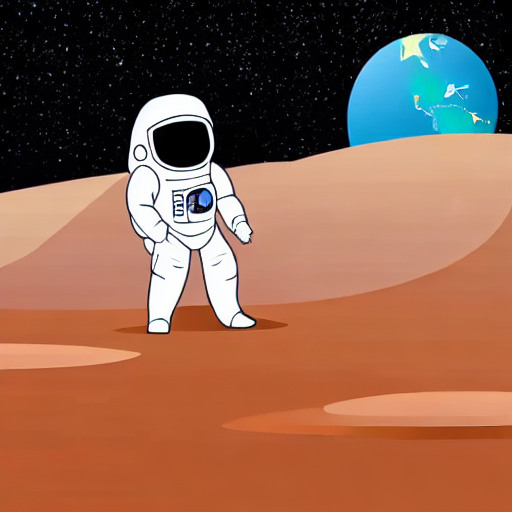

In [4]:
def generate_simple_image(prompt, negative_prompt, seed=222):
  generator = torch.Generator("cuda").manual_seed(seed)

  image_simple = pipe(
      prompt=prompt,
      negative_prompt=negative_prompt,
      generator=generator
  ).images[0]

  return image_simple

  0%|          | 0/50 [00:00<?, ?it/s]

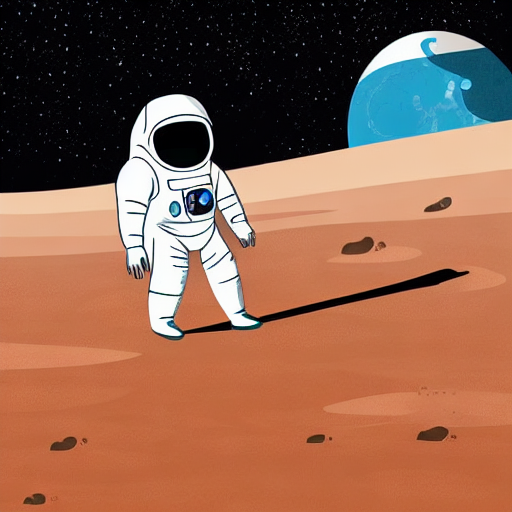

In [16]:
prompt = 'illustration of an astronaut on moon surface, earth on the background, minimal detail, 2d digital art, plain, smooth gradation'
negative_prompt = 'photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration'

simple_img = generate_simple_image(prompt=prompt, negative_prompt=negative_prompt)

simple_img

## **Generate Image with Hyperparameter Configuration (generate_advanced_image)**
Tetap gunakan Seed bernilai 222 dan negative prompt yang telah ditetapkan. Pastikan prompt yang Anda gunakan sama pada kedua fungsi agar hasilnya dapat dibandingkan secara objektif.

### **Referensi Output:**

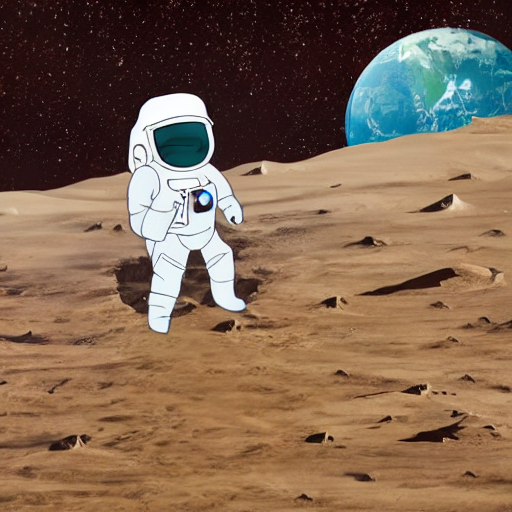

In [6]:
def generate_advanced_image(prompt, negative_prompt, guidance_scale=7.5, num_inference_steps=30, seed=222):
  generator = torch.Generator("cuda").manual_seed(seed)

  image_advanced = pipe(
      prompt=prompt,
      negative_prompt=negative_prompt,
      guidance_scale=guidance_scale,
      num_inference_steps=num_inference_steps,
      generator=generator
  ).images[0]

  return image_advanced

  0%|          | 0/35 [00:00<?, ?it/s]

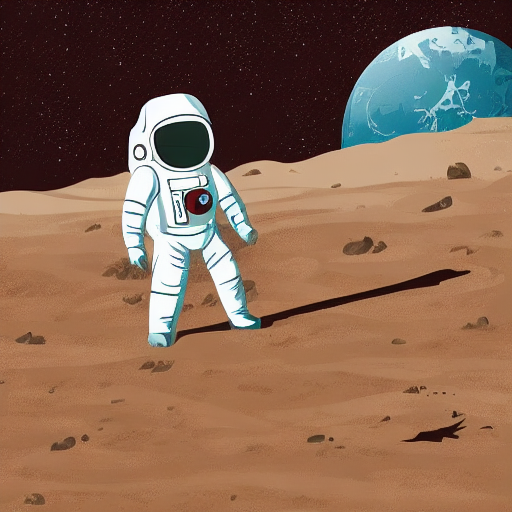

In [31]:
advanced_img = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=5,
    num_inference_steps=35
)

advanced_img

## **Guidance Scale Comparison**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

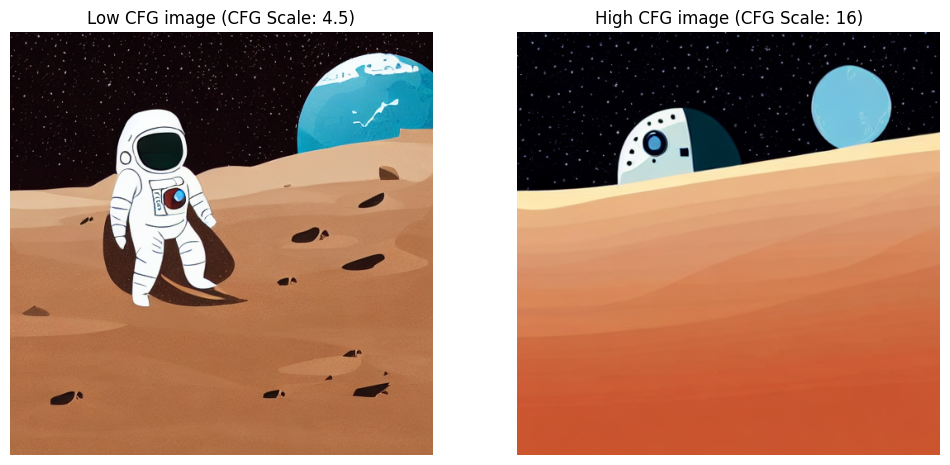

In [8]:
image_low_cfg = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=4.5,
    num_inference_steps=50
)

image_high_cfg = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=16,
    num_inference_steps=50
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image_low_cfg)
ax[0].set_title("Low CFG image (CFG Scale: 4.5)")
ax[0].axis("off")

ax[1].imshow(image_high_cfg)
ax[1].set_title("High CFG image (CFG Scale: 16)")
ax[1].axis("off")
plt.show()

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Gambar yang dihasilkan dengan parameter CFG yang rendah cenderung memiliki detail yang lebih tinggi, misalnya seperti tekstur bebatuan dan lapisan atmosfer bumi yang lebih terlihat jelas dan memiliki kedalaman. Namun hasil CFG yang rendah sering manambahkan variasi objek-objek di luar prompt seperti tekstur permukaan bulan yang tidak rata dan bebatuan. Semakin rendah CFG berarti gambar akan semakin jauh dari prompt yang diberikan seperti penambahan objek lain dan cenderung mendekati realistis"*

*   **Gambar dengan "Scale" Tinggi:**   
*"Gambar yang dihasilkan dengan parameter CFG yang tinggi cenderung lebih halus dengan semakin tingginya nilai CFG. Contohnya pada gambar diatas, tekstur bulan yang tidak rata dan memiliki batuan dan cekungan sekarang hilang menjadi sangat datar dan detail bumi juga sangat sederhana. Selain itu, CFG yang terlalu tinggi malah menghilanglan astronaut dari gambar dan menambahkan planet lain di latar belakang. Hal ini disebabkan model sangat terpaku untuk mengikuti prompt yang mana dalam prompt yang diberikan disebutkan kata 'minimal detail', 'illustration', dan '2d digital art'."*

## **Inference Steps Comparison**

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

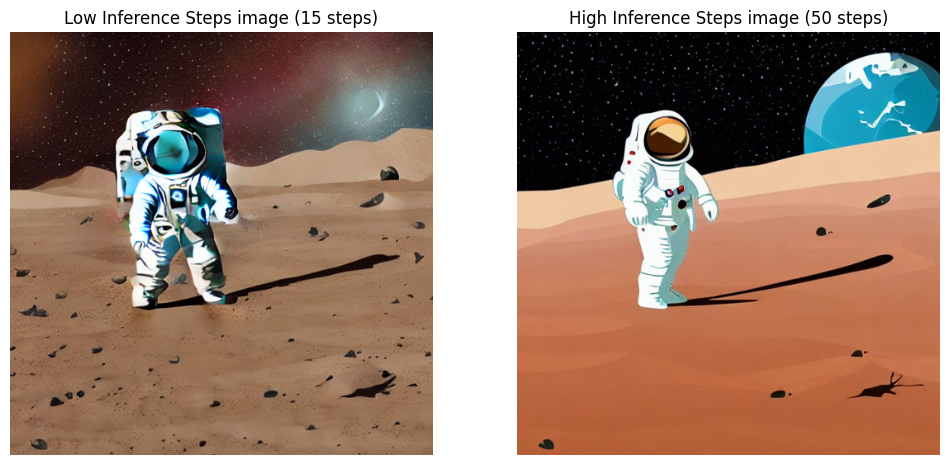

In [9]:
image_low_steps = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=7,
    num_inference_steps=15
)

image_high_steps = generate_advanced_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=7,
    num_inference_steps=50
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image_low_steps)
ax[0].set_title("Low Inference Steps image (15 steps)")
ax[0].axis("off")

ax[1].imshow(image_high_steps)
ax[1].set_title("High Inference Steps image (50 steps)")
ax[1].axis("off")
plt.show()

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Gambar yang dihasilkan dari jumlah inference step yang rendah cenderung terlihat lebih berantakan dan jauh dari prompt yang diberikan misalnya bumi di latar belakang digantinkan dengan bulan, lalu tekstur bulan yang cenderung lebih kasar dan memiliki banyak bebatuan dan cekungan. Selain itu, gambar juga terlihat lebih mendekati realistis."*
*   **Gambar dengan "Step" Tinggi:**  
*"Gambar yang dihasilkan dari jumlah inference step yang tinggi cenderung lebih stabil seperti gambar astronaut yang tidak berantakan, gambarnya juga terlihat lebih halus dan memiliki komposisi warna yang lebih kaya misalnya dengan adanya gradasi pada permukaan bulan, dan bumi juga berhasil ditampilkan di latar belakang. Secara umum, semakin tinggi inference steps, maka hasil semakin mendekati prompt."*

## **Batch Inference from One Prompt**

  0%|          | 0/50 [00:00<?, ?it/s]

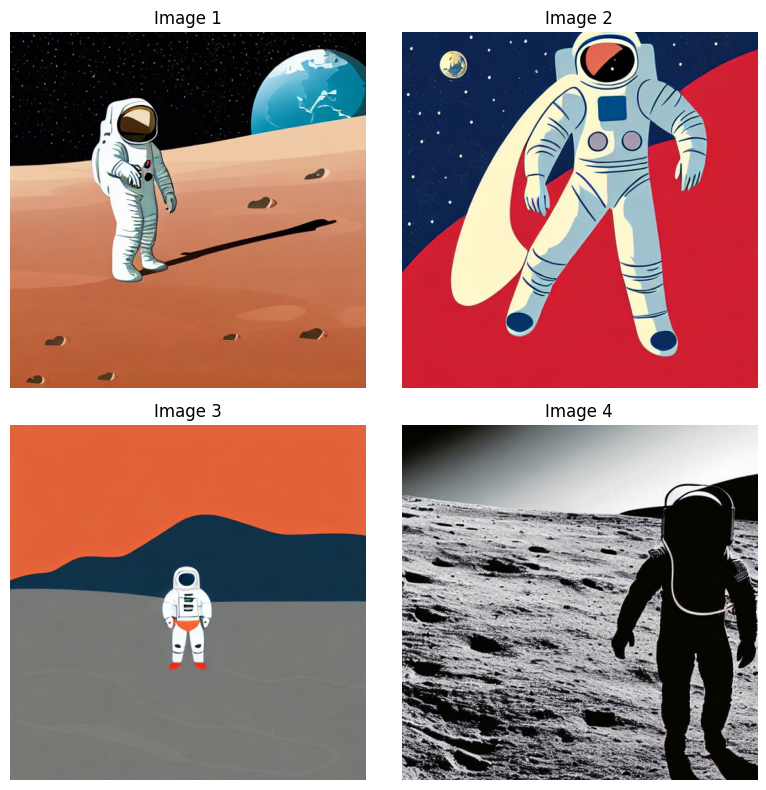

In [10]:
generator = torch.Generator("cuda").manual_seed(222)

images_batch = pipe(
    prompt=[prompt] * 4,
    negative_prompt=[negative_prompt] * 4,
    generator=generator
).images

plt.figure(figsize=(8, 8))
for i, img in enumerate(images_batch):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title('Image ' + str(i + 1))
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Load Scheduler**

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

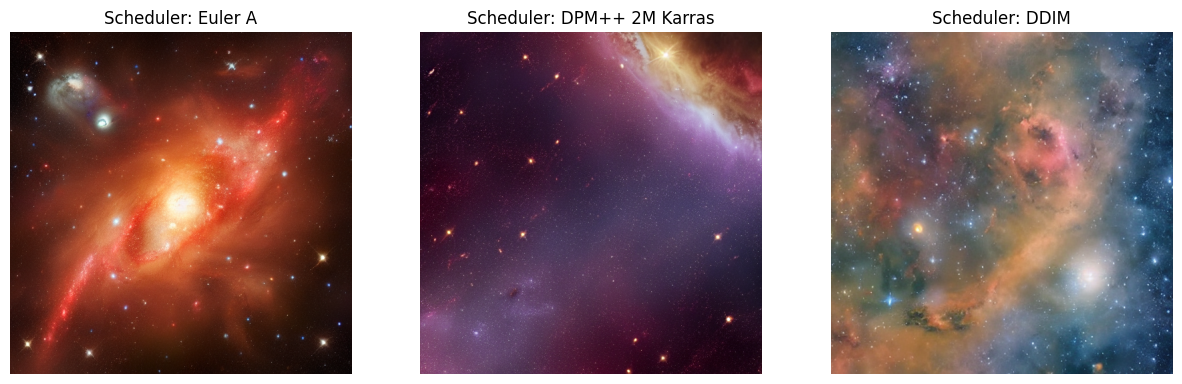

In [11]:
scheduler_configs = [
    (EulerAncestralDiscreteScheduler, "Euler A"),
    (DPMSolverMultistepScheduler, "DPM++ 2M Karras"),
    (DDIMScheduler, "DDIM")
]

prompt = 'a photorealistic space scenery with galaxies, nebulas, and stars, smooth gradient, high resolution, telescope space image quality'
negative_prompt = 'high contrast, noise, low quality'

generator = torch.Generator("cuda").manual_seed(42)

def load_scheduler(pipe, scheduler_name):
    pipe.scheduler = scheduler_name.from_config(pipe.scheduler.config)

    return pipe

images = []

for scheduler_class, name in scheduler_configs:
    pipe = load_scheduler(pipe, scheduler_class)
    
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=5,
        num_inference_steps=80
    ).images[0]
    
    images.append((name, img))

plt.figure(figsize=(15, 5))
for i, (name, img) in enumerate(images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Scheduler: {name}")
    plt.axis("off")
plt.show()

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Gambar hasil Euler A Scheduler terlihat lebih artistik dan memiliki komposisi visual yang lebih proporsional, misalnya galaxy berada di tengah sebagai objek utama kemudian tedapat nebula dan bintang-bintang yang bertebaran di latar belakang. Selain itu gambar ini juga memiliki kontras yang cukup tinggi dimana objek seperti galaxy, bintang, dan nebula terlihat terang sementara langit angkasa terlihat sangat gelap."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Gambar hasil DPM++ Scheduler terlihat lebih sederhana, tidak terdapat objek utama yang menjadi pusat perhatian, Namun memiliki gradasi warna langit angkasa yang lebih berwarna dan lebih bersih. Gambar ini juga memiliki kombinasi warna yang seimbang, sehingga tidak memiliki kontras yang terlalu tinggi."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Gambar hasil DDIM terlihat lebih menonjolkan bagian nebula. Selain itu, terdapat banyak sekali debu kosmik sampai hampir memenuhi langit angkasa yang gelap. Bintang-bintang di latar belakang pun terlihat lebih banyak dibandingkan gambar-gambar hasil dua scheduler lainnya. Selain itu, dari segi komposisi warna juga cenderung lebih terang."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Inpainting**

**Perhatian:** Gunakan gambar hasil `generate_advanced_image()` atau `generate_simple_image()` sebagai `image`, bukan gambar baru.

Hasil Inpainting yang Anda lakukan perlu dibuat semirip mungkin atau setidaknya menambahkan broken satelite seperti pada Gambar yang ditetapkan berikut ini. (Gunakan Seed bernilai 9)

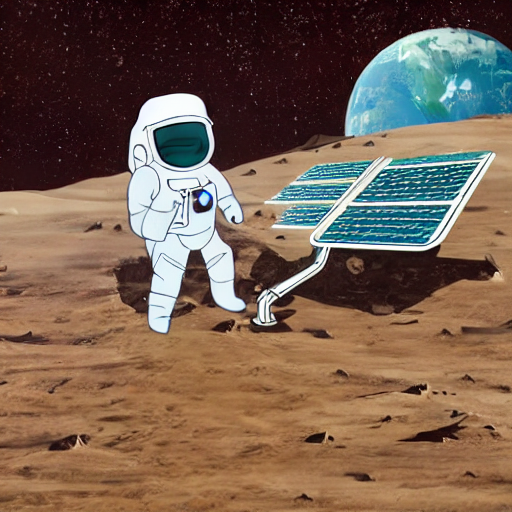

### **Load Model Inpainting**

In [12]:
model_id = "stable-diffusion-v1-5/stable-diffusion-inpainting"

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

inpaint_pipe = inpaint_pipe.to("cuda")
inpaint_pipe.enable_attention_slicing()

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing netw

### **Manual Masking**

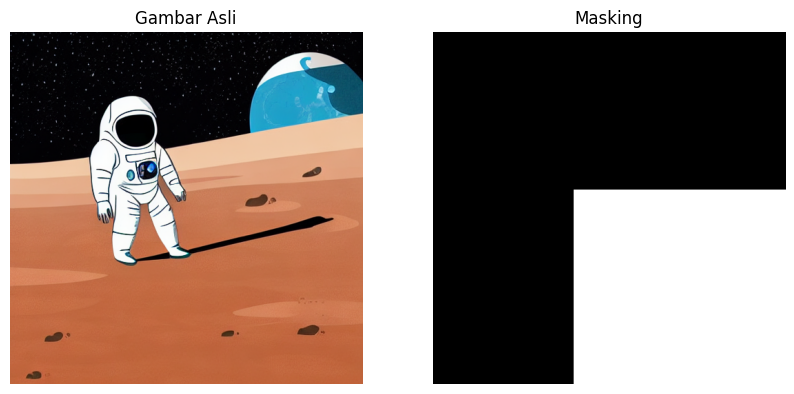

In [40]:
mask = Image.new("L", simple_img.size, 0)
draw = ImageDraw.Draw(mask)

width, height = simple_img.size

# Koordinat mask untuk menutupi seluruh area mobil
left = width * 0.40
top = height * 0.45
right = width * 1.00
bottom = height * 1.00

# Kotak putih di area mobil
draw.rectangle((left, top, right, bottom), fill=255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(simple_img)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masking")
plt.axis("off")
plt.show()

### **Generate**

In [14]:
def inpaint_engine(image, mask, prompt, negative_prompt):
    generator = torch.Generator("cuda").manual_seed(9)

    image_inpainting = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        guidance_scale=10,
        num_inference_steps=95,
        strength=0.95,
        generator=generator
    ).images[0]

    return image_inpainting

  0%|          | 0/90 [00:00<?, ?it/s]

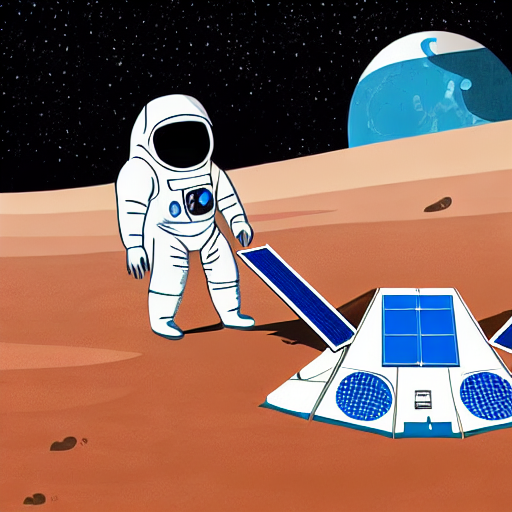

In [64]:
prompt = "a damaged broken satellite with blue solar panels crashed on the moon surface, lunar surface with craters, metallic debris, broken panels, exposed mechanical parts"

negative_prompt = "circular, round, distorted, messy, blurry, low quality"

inpaint_img = inpaint_engine(simple_img, mask, prompt, negative_prompt)

inpaint_img

## **Inpainting Menggunakan Automasking**

Anda bebas untuk melakukan inpainting di area manapun menggunakan model segmentation. Terapkan inpainting pada gambar hasil inpainting manual di level basic sebelumnya.

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

**Perhatian:** Gunakan gambar hasil inpainting (manual atau otomatis) sebagai input pada tahap ini.

Pastikan outpainting yang dilakukan mendekati gambar yang diharapkan di bawah ini dan terlihat natural dan masih berhubungan dengan gambar dasar.

###**Referensi Expected Output:**

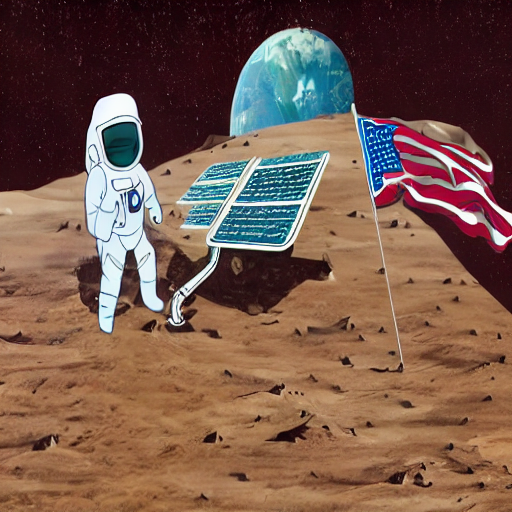

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

**Perhatian:** Gunakan gambar hasil outpainting sebelumnya sebagai input pada tahap ini.

Pada tahap ini Anda tidak diharuskan untuk meniru spesifik satu gambar saja, tetapi berikut beberapa output yang dapat dijadikan referensi.

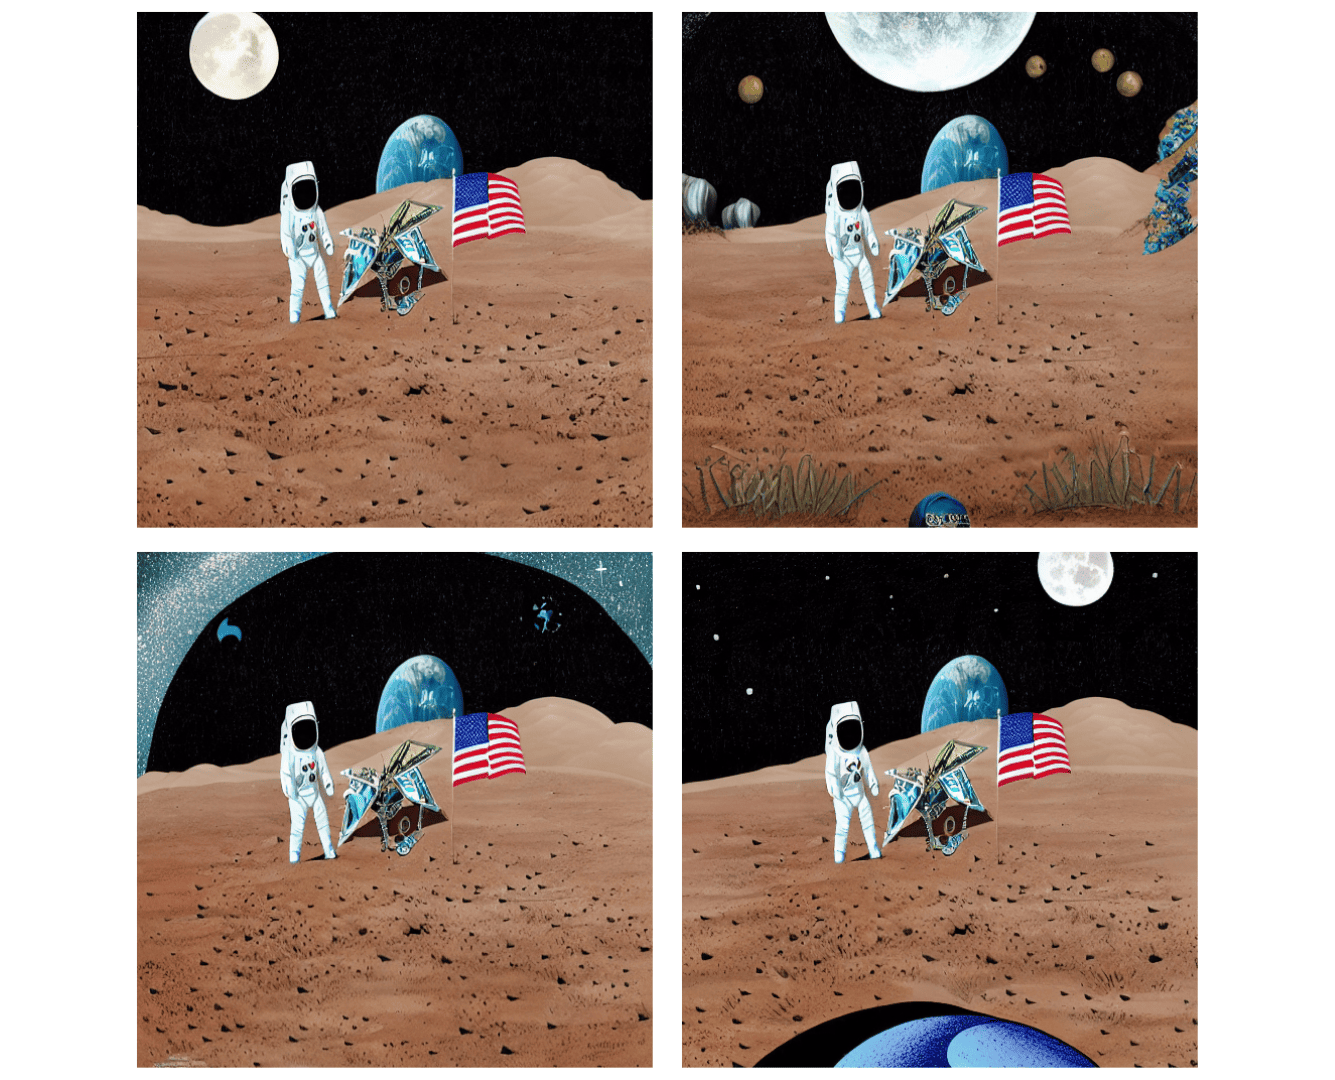

### **Prepare Canvas for Zoom Out**

### **Generate**

## **Base + Refiner Image Generation**